In [1]:
import pandas as pd
import networkx as nx

#Create Network

In [5]:
# Load the paper-author relationships
df_paper_author = pd.read_csv("GraphDataset/paper_author.csv")

# Initialize an undirected graph for co-authorship
G_coauthor = nx.Graph()

# Add all authors as nodes first
unique_authors = df_paper_author["author_id"].unique()
G_coauthor.add_nodes_from(unique_authors)

# Group by paper to get a list of authors for each paper
paper_groups = df_paper_author.groupby("paper_id")["author_id"].apply(list)

# For each paper, add edges between all pairs of authors if multiple authors exist
for paper, authors in paper_groups.items():
    # Skip papers with single authors (they're already nodes)
    if len(authors) < 2:
        continue
    # Create edges between all pairs of authors in the paper
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            author1, author2 = authors[i], authors[j]
            if G_coauthor.has_edge(author1, author2):
                # Increment weight if edge already exists
                G_coauthor[author1][author2]["weight"] += 1
            else:
                G_coauthor.add_edge(author1, author2, weight=1)

# Add author names as node attributes
df_authors = pd.read_csv("GraphDataset/author.csv")
author_names = dict(zip(df_authors["node_id"], df_authors["name"]))
nx.set_node_attributes(G_coauthor, author_names, "name")

# Print basic info about the co-authorship network
print("Co-Authorship Network:")
print("Number of author nodes:", G_coauthor.number_of_nodes())
print("Number of co-authorship links:", G_coauthor.number_of_edges())

# Example: Print first 5 edges with weights
print("\nSample of co-authorship edges with weights:")
for edge in list(G_coauthor.edges(data=True))[:5]:
    print(edge)


Co-Authorship Network:
Number of author nodes: 18522
Number of co-authorship links: 241405

Sample of co-authorship edges with weights:
('author_1', 'author_2', {'weight': 1})
('author_2', 'author_9496', {'weight': 1})
('author_2', 'author_3432', {'weight': 2})
('author_2', 'author_3434', {'weight': 2})
('author_2', 'author_3141', {'weight': 2})


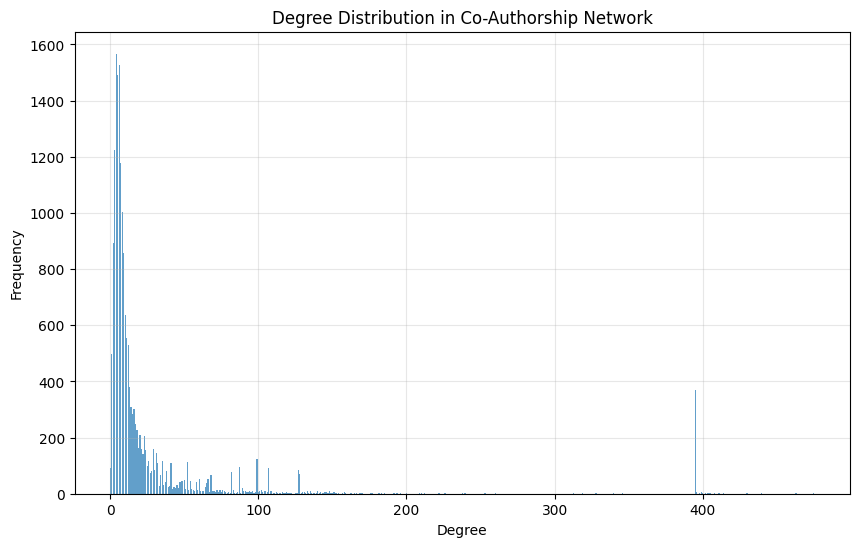


Degree Statistics:
Average degree: 26.07
Maximum degree: 475
Minimum degree: 0


In [31]:
# Calculate degree distribution
degrees = [d for n, d in G_coauthor.degree()]
degree_counts = pd.Series(degrees).value_counts().sort_index()

# Plot degree distribution as bar chart
plt.figure(figsize=(10, 6))
plt.bar(degree_counts.index, degree_counts.values, alpha=0.7)
plt.xlabel('Degree')
plt.ylabel('Frequency') 
plt.title('Degree Distribution in Co-Authorship Network')
plt.grid(True, alpha=0.3)
plt.show()

# Print some basic degree statistics
print("\nDegree Statistics:")
print(f"Average degree: {sum(degrees)/len(degrees):.2f}")
print(f"Maximum degree: {max(degrees)}")
print(f"Minimum degree: {min(degrees)}")


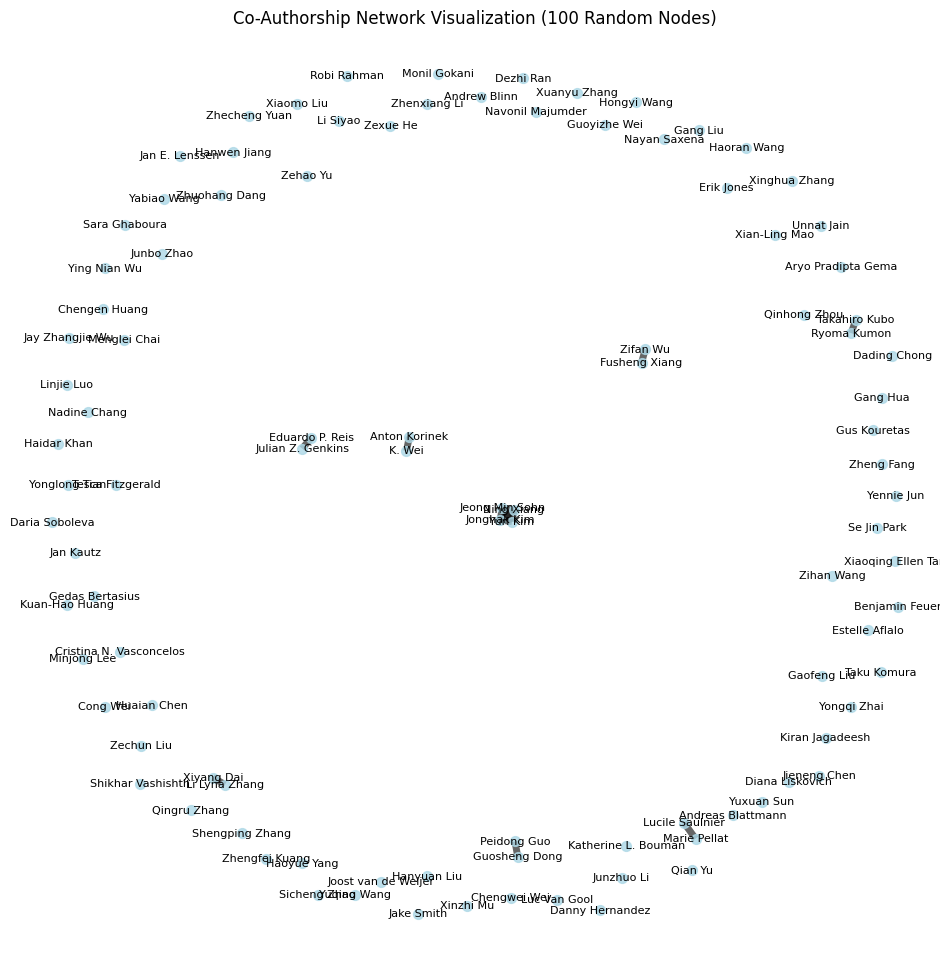

In [28]:
import matplotlib.pyplot as plt
import networkx as nx
import random

# Assuming G_coauthor has been created from your paper-author data

# Extract the largest connected component
largest_cc = max(nx.connected_components(G_coauthor), key=len)
G_lcc = G_coauthor.subgraph(largest_cc).copy()

# Randomly sample 100 nodes
sample_nodes = random.sample(list(G_lcc.nodes()), min(100, len(G_lcc.nodes())))
G_sample = G_lcc.subgraph(sample_nodes).copy()

# Use a spring layout for visualization (seed for reproducibility)
pos = nx.spring_layout(G_sample, seed=42)

# Draw nodes with a fixed small size
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G_sample, pos, node_size=50, node_color='lightblue', alpha=0.8)

# Scale edge widths based on the 'weight' attribute
edges = G_sample.edges(data=True)
edge_weights = [data['weight'] for (_, _, data) in edges]
max_weight = max(edge_weights) if edge_weights else 1
# Normalize edge widths (scaling factor can be adjusted)
edge_widths = [max(0.1, (w / max_weight * 5)) for w in edge_weights]

nx.draw_networkx_edges(G_sample, pos, width=edge_widths, alpha=0.6)

# Draw labels for all nodes
labels = {node: G_sample.nodes[node].get("name", node) for node in G_sample.nodes()}
nx.draw_networkx_labels(G_sample, pos, labels, font_size=8)

plt.title("Co-Authorship Network Visualization (100 Random Nodes)")
plt.axis('off')
plt.show()


#Compute Metrics

In [ ]:
# 1. Degree Centrality
degree_centrality = nx.degree_centrality(G_coauthor)

# 2. Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G_coauthor, weight="weight")

# 3. PageRank (choose one) OR Eigenvector Centrality
pagerank = nx.pagerank(G_coauthor, weight="weight")
# OR
# eigenvector_centrality = nx.eigenvector_centrality(G_coauthor, weight="weight", max_iter=500)

# Convert centralities to DataFrames
df_dc = pd.DataFrame(list(degree_centrality.items()), columns=["node", "degree_centrality"])
df_bc = pd.DataFrame(list(betweenness_centrality.items()), columns=["node", "betweenness_centrality"])
df_pr = pd.DataFrame(list(pagerank.items()), columns=["node", "pagerank"])

# If you choose Eigenvector instead of PageRank:
# df_ec = pd.DataFrame(list(eigenvector_centrality.items()), columns=["node", "eigenvector_centrality"])

# Merge them into one DataFrame
df_centralities = df_dc.merge(df_bc, on="node").merge(df_pr, on="node")
# If using Eigenvector, merge that as well:
# df_centralities = df_centralities.merge(df_ec, on="node")

# Optional: If your graph nodes have an attribute "name", let's add that too
# e.g., if G_coauthor.nodes[node]["name"] = author_name
names = []
for node in df_centralities["node"]:
    author_name = G_coauthor.nodes[node].get("name", str(node))  # fallback to node ID if name missing
    names.append(author_name)
df_centralities["author_name"] = names

# Sort the combined DataFrame by degree centrality (descending)
df_centralities.sort_values("degree_centrality", ascending=False, inplace=True)

# Show top 10 authors by degree centrality
print("\nTop 10 Authors by Degree Centrality:")
print(df_centralities[["author_name", "degree_centrality"]].head(10))

# Show top 10 by betweenness
df_centralities.sort_values("betweenness_centrality", ascending=False, inplace=True)
print("\nTop 10 Authors by Betweenness Centrality:")
print(df_centralities[["author_name", "betweenness_centrality"]].head(10))

# Show top 10 by PageRank
df_centralities.sort_values("pagerank", ascending=False, inplace=True)
print("\nTop 10 Authors by PageRank:")
print(df_centralities[["author_name", "pagerank"]].head(10))

# If you computed Eigenvector Centrality, you can do:
# df_centralities.sort_values("eigenvector_centrality", ascending=False, inplace=True)
# print("\nTop 10 Authors by Eigenvector Centrality:")
# print(df_centralities[["author_name", "eigenvector_centrality"]].head(10))


In [ ]:
# Save to CSV
df_centralities.to_csv("coauthor_centralities.csv", index=False)

# Or save to JSON
df_centralities.to_json("coauthor_centralities.json", orient="records")